<a href="https://colab.research.google.com/github/ParushiSrivastava/PARUSHI.23FE10CSE00380/blob/main/ete_ml_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import tree
import os

In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("altruistdelhite04/loan-prediction-problem-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'loan-prediction-problem-dataset' dataset.
Path to dataset files: /kaggle/input/loan-prediction-problem-dataset


In [18]:

for root, dirs, files in os.walk(path):
    for file in files:
        print(file)

test_Y3wMUE5_7gLdaTN.csv
train_u6lujuX_CVtuZ9i.csv


In [20]:

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)


le = LabelEncoder()

columns = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in columns:
    df[col] = le.fit_transform(df[col])


df = df.drop('Loan_ID', axis=1, errors='ignore')


/tmp/ipykernel_19711/2448818049.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_19711/2448818049.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

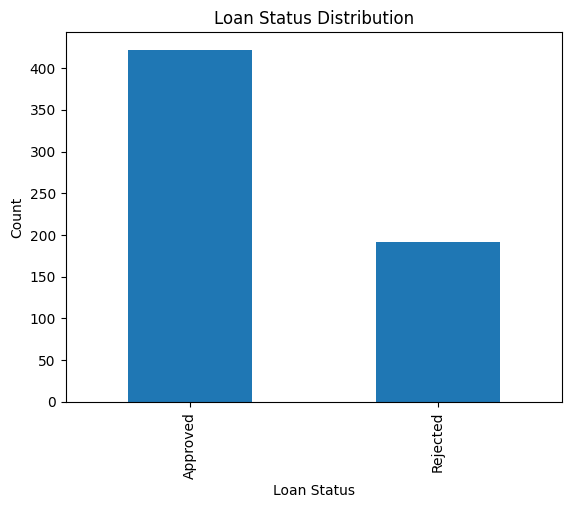

<Figure size 640x480 with 0 Axes>

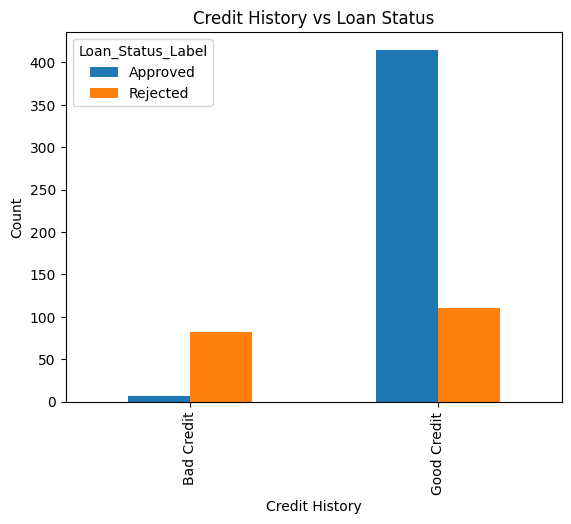

In [26]:

df['Loan_Status_Label'] = df['Loan_Status'].map({
    0: "Rejected",
    1: "Approved"
})

df['Credit_History_Label'] = df['Credit_History'].map({
    0: "Bad Credit",
    1: "Good Credit"
})

plt.figure()
df['Loan_Status_Label'].value_counts().plot(kind='bar')

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()


plt.figure()
pd.crosstab(
    df['Credit_History_Label'],
    df['Loan_Status_Label']
).plot(kind='bar')

plt.title("Credit History vs Loan Status")
plt.xlabel("Credit History")
plt.ylabel("Count")

plt.show()


In [29]:


df_model = df.drop(
    ['Loan_Status_Label', 'Credit_History_Label'],
    axis=1,
    errors='ignore'
)


X = df_model.drop('Loan_Status', axis=1)
y = df_model['Loan_Status']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [30]:
# Predict
y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)






Accuracy: 0.7560975609756098

Confusion Matrix:
 [[18 25]
 [ 5 75]]


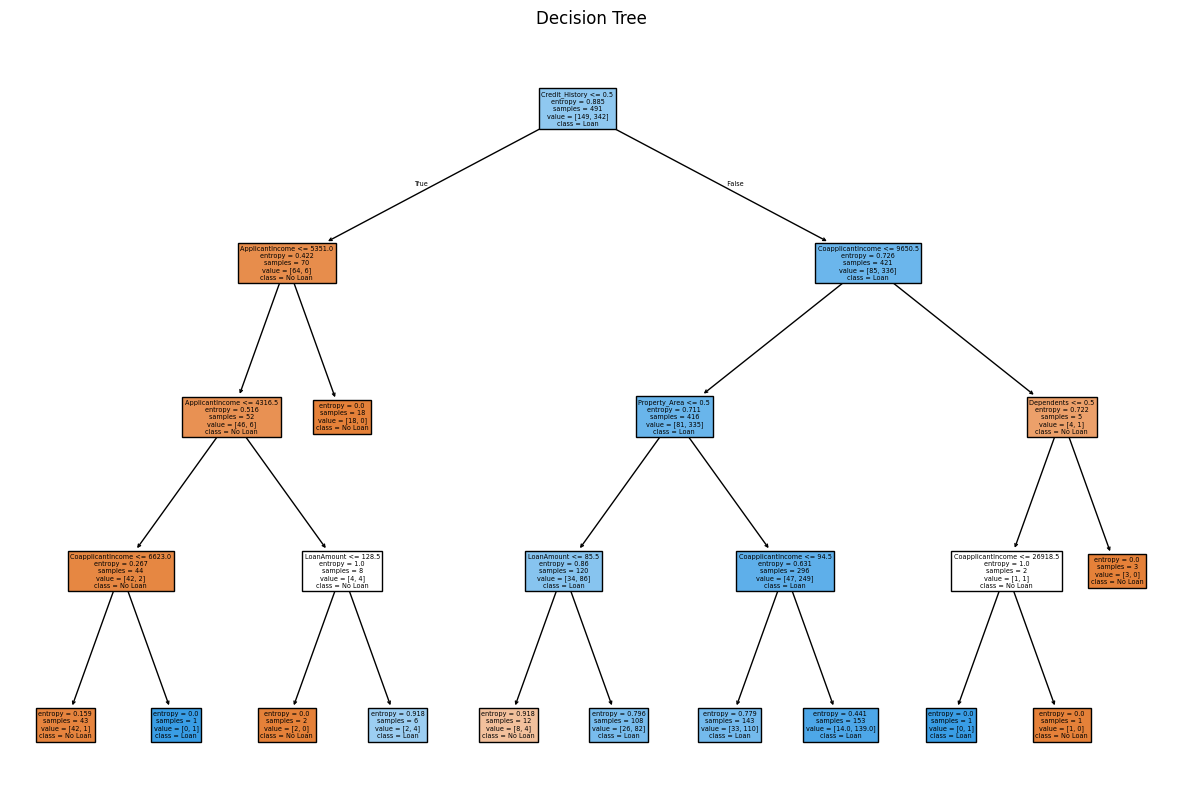

In [31]:
plt.figure(figsize=(15,10))

tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No Loan', 'Loan'],
    filled=True
)

plt.title("Decision Tree")
plt.show()